In [ ]:
%pip install torch

In [31]:
import torch
import math
import torch.nn as nn  
import matplotlib.pyplot as plt
import numpy as np 

In [10]:
x = torch.tensor([5.0], requires_grad=True)
loss = (x - 3) ** 2
loss.backward()
print(f"Градиент loss по x: {x.grad.item()}")


Градиент loss по x: 4.0


In [11]:
learning_rate = 0.1
x_new = x - learning_rate * x.grad
print(f"Было x = {x.item():.4f}")
print(f"Градиент = {x.grad.item():.4f}")
print(f"Стало x = {x_new.item():.4f}")


Было x = 5.0000
Градиент = 4.0000
Стало x = 4.6000


In [12]:
new_loss = (x_new - 3) ** 2
print(f"Была ошибка = {loss.item():.4f}, стала = {new_loss.item():.4f}")

Была ошибка = 4.0000, стала = 2.5600


In [ ]:
x = torch.tensor([5.0], requires_grad=True)

for step in range(20):
    loss = (x - 3) ** 2
    

    if x.grad is not None:
        x.grad.zero_()  
    
    loss.backward()
    
    with torch.no_grad():  
        x -= 0.1 * x.grad
    
    if step % 5 == 0:
        print(f"Шаг {step}: x = {x.item():.4f}, ошибка = {loss.item():.4f}")

print(f"Финальное x = {x.item():.4f}")

Шаг 0: x = 4.6000, ошибка = 4.0000
Шаг 5: x = 3.5243, ошибка = 0.4295
Шаг 10: x = 3.1718, ошибка = 0.0461
Шаг 15: x = 3.0563, ошибка = 0.0050
Финальное x = 3.0231


In [16]:
# Создаем два параметра: вес w и смещение b
w = torch.tensor([2.0], requires_grad=True)
b = torch.tensor([1.0], requires_grad=True)

x_in = 5.0

# Прямой проход: вычисляем предсказание
y_pred = w * x_in + b

# Целевое значение 
y_true = 15.0

# Ошибка — квадрат разницы
loss = (y_pred - y_true) ** 2

# Вычисляем градиенты для w и b
loss.backward()

print(f"Градиент по w: {w.grad.item():.4f}")
print(f"Градиент по b: {b.grad.item():.4f}")

# Делаем шаг оптимизации
learning_rate = 0.01
with torch.no_grad():
    w -= learning_rate * w.grad
    b -= learning_rate * b.grad

print(f"Новый w = {w.item():.4f}, новый b = {b.item():.4f}")

Градиент по w: -40.0000
Градиент по b: -8.0000
Новый w = 2.4000, новый b = 1.0800


In [18]:
x_data = torch.tensor([0.0, 1.0, 2.0, 3.0, 4.0])
y_data = torch.tensor([1.2, 2.9, 5.1, 6.8, 9.0])  

# Параметры модели (начинаем с нуля)
w = torch.tensor([0.0], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

learning_rate = 0.01

for epoch in range(100):
    # Предсказания для всех 5 точек сразу
    y_pred = w * x_data + b
    
    # Среднеквадратичная ошибка (MSE)
    loss = ((y_pred - y_data) ** 2).mean()
    
    # Обнуляем градиенты
    if w.grad is not None:
        w.grad.zero_()
        b.grad.zero_()
    
    # Вычисляем градиенты
    loss.backward()
    
    # Обновляем параметры
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad
    
    if epoch % 20 == 0:
        print(f"Эпоха {epoch:3d}: w={w.item():.4f}, b={b.item():.4f}, ошибка={loss.item():.4f}")

print(f"\nИтог: w ≈ {w.item():.4f}, b ≈ {b.item():.4f}")

Эпоха   0: w=0.2780, b=0.1000, ошибка=32.6200
Эпоха  20: w=1.9633, b=0.7378, ошибка=0.1542
Эпоха  40: w=2.0460, b=0.8082, ошибка=0.0438
Эпоха  60: w=2.0399, b=0.8428, ошибка=0.0374
Эпоха  80: w=2.0300, b=0.8719, ошибка=0.0326

Итог: w ≈ 2.0214, b ≈ 0.8964


In [ ]:
# Те же данные
x_data = torch.tensor([0.0, 1.0, 2.0, 3.0, 4.0])
y_data = torch.tensor([1.2, 2.9, 5.1, 6.8, 9.0])

# Параметры
w = torch.tensor([0.0], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

# Оптимизатор SGD - будет обновлять w и b
# lr = learning rate
optimizer = torch.optim.SGD([w, b], lr=0.01)

for epoch in range(100):
    # Прямой проход
    y_pred = w * x_data + b
    loss = ((y_pred - y_data) ** 2).mean()
    
    optimizer.zero_grad()  # обнуляем градиенты
    loss.backward()        # вычисляем градиенты
    optimizer.step()       # обновляем параметры
    
    if epoch % 20 == 0:
        print(f"Эпоха {epoch:3d}: w={w.item():.4f}, b={b.item():.4f}, ошибка={loss.item():.4f}")

Эпоха   0: w=0.2780, b=0.1000, ошибка=32.6200
Эпоха  20: w=1.9633, b=0.7378, ошибка=0.1542
Эпоха  40: w=2.0460, b=0.8082, ошибка=0.0438
Эпоха  60: w=2.0399, b=0.8428, ошибка=0.0374
Эпоха  80: w=2.0300, b=0.8719, ошибка=0.0326


In [ ]:
# Определяем класс нашей нейросети
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Первый слой: из 1 входа делаем 10 нейронов
        self.hidden = nn.Linear(1, 10)
        # Второй слой: из 10 нейронов делаем 1 выход
        self.output = nn.Linear(10, 1)
        # Функция активации ReLU 
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # Прямой проход: x -> скрытый слой -> ReLU -> выходной слой
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x

# Создаем модель
model = SimpleNet()

# Оптимизатор Adam 
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Функция потерь — MSE
criterion = nn.MSELoss()

# Обучающие данные: 100 точек от -3 до 3, y = sin(x) + шум
x_data = torch.linspace(-3, 3, 100).reshape(-1, 1)
y_data = torch.sin(x_data) + torch.randn_like(x_data) * 0.1

# Обучение
for epoch in range(500):
    # Прямой проход
    y_pred = model(x_data)
    loss = criterion(y_pred, y_data)
    
    # Обратный проход
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 100 == 0:
        print(f"Эпоха {epoch+1:4d}, ошибка = {loss.item():.6f}")


# Проверяем предсказание для одной точки
test_x = torch.tensor([[0.5]])
test_y = model(test_x)
print(f"Для x=0.5 нейросеть предсказывает y ≈ {test_y.item():.4f}")
print(f"Истинный sin(0.5) ≈ {math.sin(0.5):.4f}")

Эпоха  100, ошибка = 0.059313
Эпоха  200, ошибка = 0.026758
Эпоха  300, ошибка = 0.016702
Эпоха  400, ошибка = 0.012443
Эпоха  500, ошибка = 0.010496
Для x=0.5 нейросеть предсказывает y ≈ 0.5225
Истинный sin(0.5) ≈ 0.4794


In [ ]:
# Создаем ТЕСТОВЫЕ данные (20 новых точек)
x_test = torch.linspace(-3, 3, 20).reshape(-1, 1)
y_test_true = torch.sin(x_test)  
y_test_pred = model(x_test)       

# Считаем MSE
mse = ((y_test_pred - y_test_true) ** 2).mean().item()

print(f"(MSE) на тесте = {mse:.6f}")


(MSE) на тесте = 0.003994


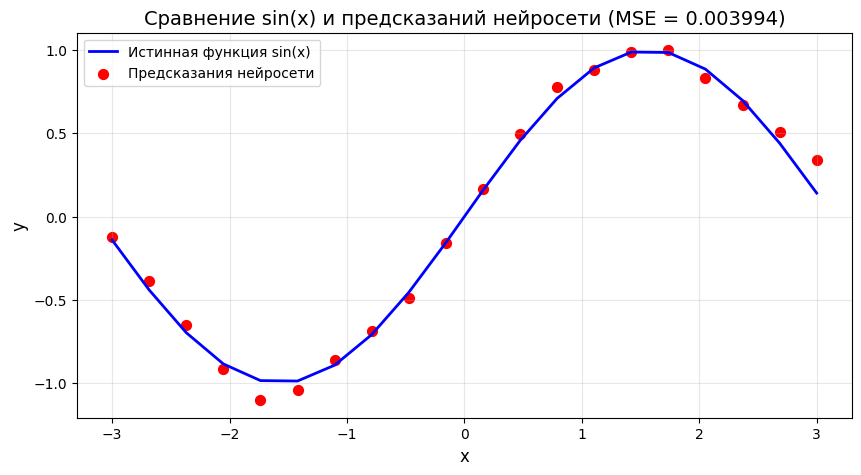

In [ ]:
x_test_np = x_test.numpy().flatten()
y_true_np = y_test_true.numpy().flatten()
y_pred_np = y_test_pred.detach().numpy().flatten()

plt.figure(figsize=(10, 5))

plt.plot(x_test_np, y_true_np, 'b-', linewidth=2, label='Истинная функция sin(x)')

plt.scatter(x_test_np, y_pred_np, c='red', s=50, label='Предсказания нейросети')

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title(f'Сравнение sin(x) и предсказаний нейросети (MSE = {mse:.6f})', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


In [32]:
print("\nСравнение предсказаний с истинными значениями:")
print("-" * 50)
print(f"{'x':>8} | {'Истинный sin(x)':>16} | {'Предсказание':>12} | {'Ошибка':>10}")
print("-" * 50)

for i in range(len(x_test_np)):
    x_val = x_test_np[i]
    true_val = y_true_np[i]
    pred_val = y_pred_np[i]
    error = abs(true_val - pred_val)
    print(f"{x_val:8.3f} | {true_val:16.6f} | {pred_val:12.6f} | {error:10.6f}")

print("-" * 50)
print(f"Средняя абсолютная ошибка (MAE): {np.mean(np.abs(y_true_np - y_pred_np)):.6f}")
print(f"Корень из MSE (RMSE): {np.sqrt(mse):.6f}")


Сравнение предсказаний с истинными значениями:
--------------------------------------------------
       x |  Истинный sin(x) | Предсказание |     Ошибка
--------------------------------------------------
  -3.000 |        -0.141120 |    -0.123594 |   0.017526
  -2.684 |        -0.441601 |    -0.388415 |   0.053186
  -2.368 |        -0.698409 |    -0.653237 |   0.045172
  -2.053 |        -0.886146 |    -0.918059 |   0.031913
  -1.737 |        -0.986246 |    -1.104243 |   0.117997
  -1.421 |        -0.988809 |    -1.043776 |   0.054967
  -1.105 |        -0.893582 |    -0.865036 |   0.028546
  -0.789 |        -0.709983 |    -0.686050 |   0.023933
  -0.474 |        -0.456168 |    -0.486839 |   0.030670
  -0.158 |        -0.157240 |    -0.159495 |   0.002256
   0.158 |         0.157240 |     0.167848 |   0.010608
   0.474 |         0.456168 |     0.495191 |   0.039023
   0.789 |         0.709983 |     0.776246 |   0.066264
   1.105 |         0.893582 |     0.882038 |   0.011544
   1.421 |